# EDA Retail Sales Analysis

## Import Required Libraries


In [ ]:
# =====================================
# IMPORT REQUIRED LIBRARIES
# =====================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset and Initial Inspection

In [29]:
# Load the Dataset
df = pd.read_csv("dataset/retail_sales_dataset.csv")

# DatasetShape
print("Dataset Shape:")
print(df.shape)
# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Info:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# First 5 rows
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(1000, 9)

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

Missing Values:
Transaction ID      0
Date                0
Cu

## DESCRIPTIVE STATISTICS

In [27]:

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Mean of Numerical Variables
print("===== MEAN =====\n", num_cols.mean())

# Median of Numerical Variables
print("\n===== MEDIAN =====")
print(num_cols.median())

# Modeof Numerical Variables
print("\n===== MODE =====")
print(num_cols.mode().iloc[0])

# Standard Deviation of Numerical Variables
print("\n===== STANDARD DEVIATION =====")
print(num_cols.std())

# Complete descriptive statistics
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

===== MEAN =====
 Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

===== MEDIAN =====
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

===== MODE =====
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

===== STANDARD DEVIATION =====
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

===== DESCRIPTIVE STATISTICS =====
       Transaction ID                        Date         Age     Quantity  \
count     1000.000000                        1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000    41.39200     2.514000   
min          1.000000         2023-01-01 00:00:00    18.00000  

## Time Series Analysis

Monthly Sales
Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


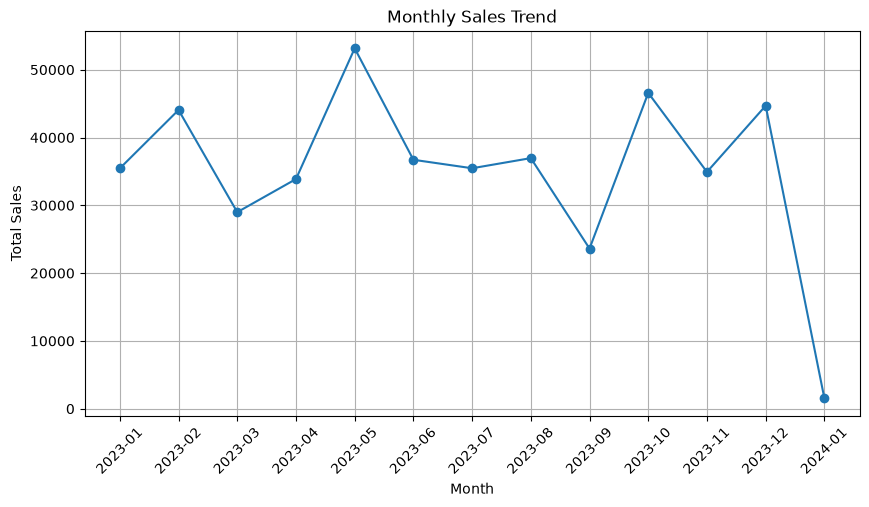


Quarterly Sales
Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


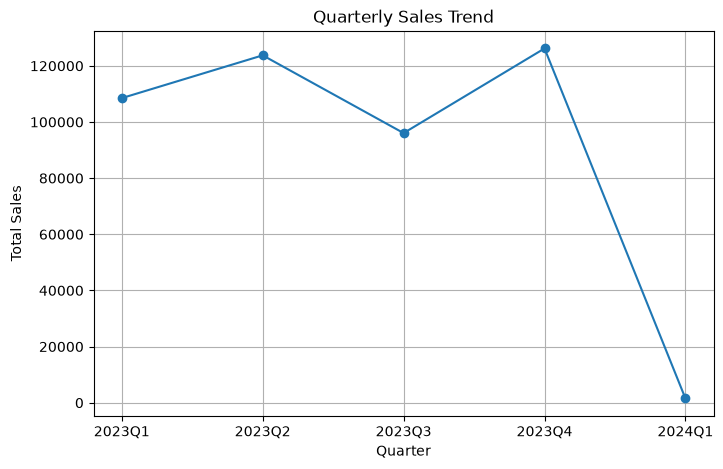

In [ ]:

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])


# Monthly Sales Trend Analysis

monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

print("Monthly Sales")
print(monthly_sales)


plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Quarterly Sales Trend Analysis

quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

print("\nQuarterly Sales")
print(quarterly_sales)

plt.figure(figsize=(8,5))
plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Time Series Analysis

Monthly Sales Trend:
Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


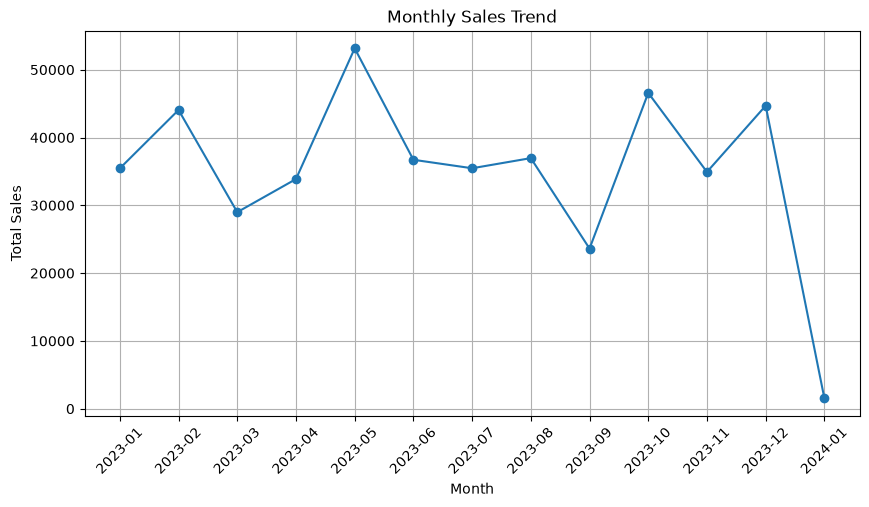

In [21]:

# Convert the Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Group the data by month and calculate total sales
monthly_sales = (
    df.groupby(
        df['Date'].dt.to_period('M')
    )['Total Amount']
    .sum()
)

# Display monthly sales values
print("Monthly Sales Trend:")
print(monthly_sales)

# Create figure
plt.figure(figsize=(10,5))

# Plot monthly sales trend
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

# Add chart title
plt.title('Monthly Sales Trend')

# Add x-axis label
plt.xlabel('Month')

# Add y-axis label
plt.ylabel('Total Sales')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add grid lines
plt.grid(True)

# Display chart
plt.show()

## Customer Demographics Analysis

Dataset Shape:
(1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Customer Age Group Distribution:
Age_Group
0-20      63
21-30    210
31-40    193
41-50    221
51-60    220
60+       93
Name: count, dtype: int64


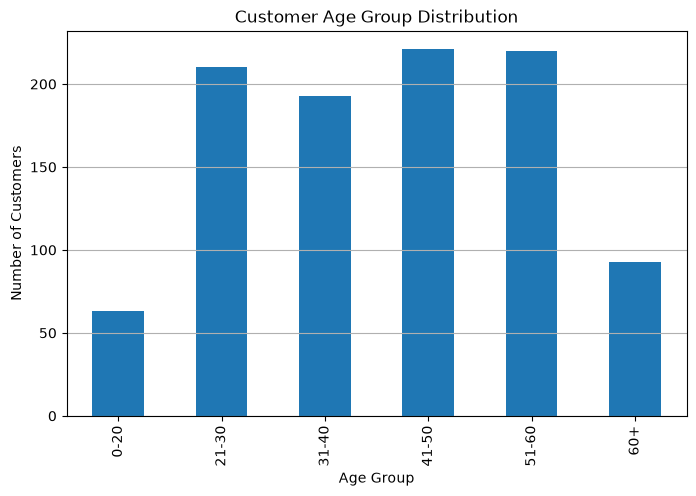


Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64


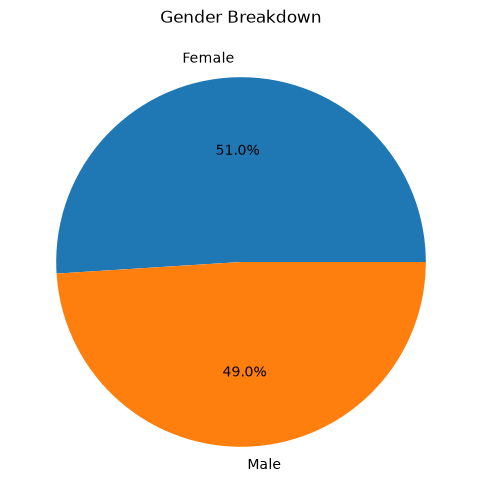


Age Group vs Gender:
Gender     Female  Male
Age_Group              
0-20           36    27
21-30         103   107
31-40          97    96
41-50         116   105
51-60         116   104
60+            42    51


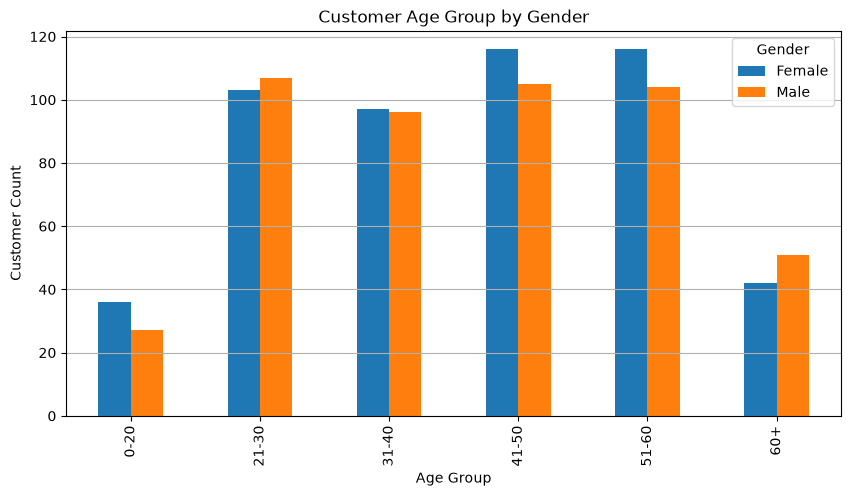

In [ ]:

# Data Information
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# Age Group Distribution
bins = [0, 20, 30, 40, 50, 60, 100]
labels = [
    '0-20',
    '21-30',
    '31-40',
    '41-50',
    '51-60',
    '60+'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

# Customer Age Group Distribution
age_distribution = (
    df['Age_Group']
    .value_counts()
    .sort_index()
)

print("\nCustomer Age Group Distribution:")
print(age_distribution)

plt.figure(figsize=(8,5))
age_distribution.plot(
    kind='bar'
)
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.grid(axis='y')
plt.show()

# Gender Distribution Analysis
gender_distribution = df['Gender'].value_counts()

print("\nGender Distribution:")
print(gender_distribution)

plt.figure(figsize=(6,6))
gender_distribution.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Gender Breakdown")
plt.ylabel("")
plt.show()

# Age Group vs Gender Analysis
age_gender = pd.crosstab(
    df['Age_Group'],
    df['Gender']
)

print("\nAge Group vs Gender:")
print(age_gender)

age_gender.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Customer Age Group by Gender")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")
plt.legend(title="Gender")
plt.grid(axis='y')
plt.show()

## Product Analysis

Top Selling Product Categories:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


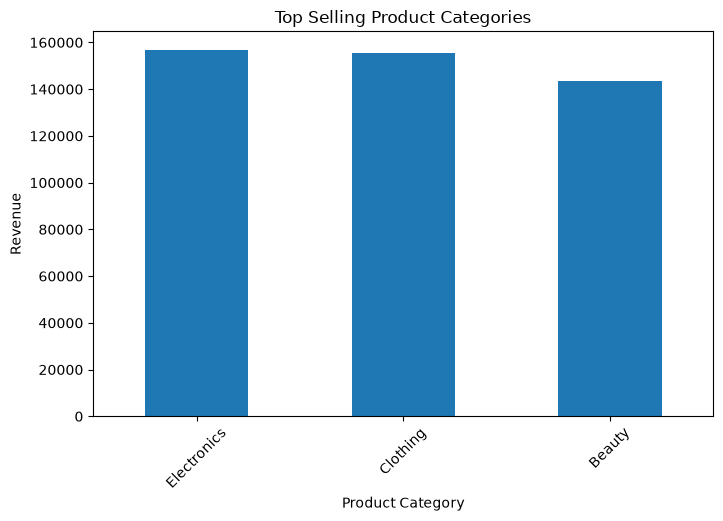

Revenue by Product Category:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


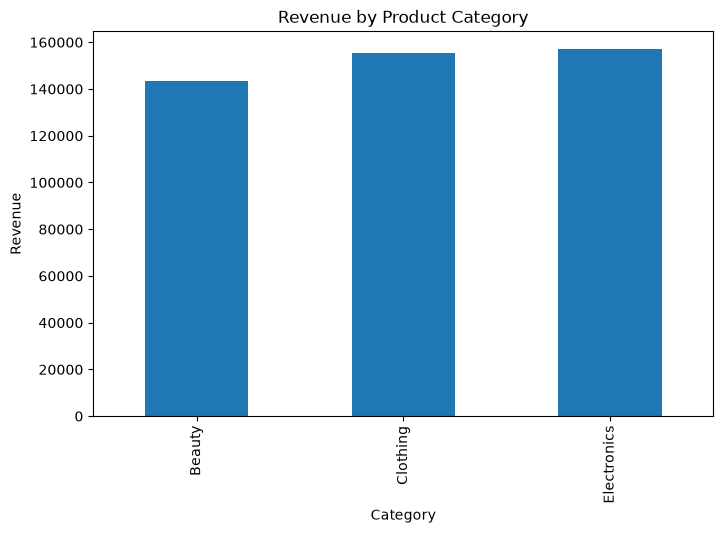

In [23]:

# Top Selling Product Categories Analysis
top_products = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    
    # Sort categories from highest revenue to lowest revenue
    .sort_values(ascending=False)
    
    # Select top 10 categories
    # (In this dataset only 3 categories exist)
    .head(10)
)

# Display the result
print("Top Selling Product Categories:")
print(top_products)

# Create a new figure with width=8 and height=5
plt.figure(figsize=(8,5))

# Plot the bar chart
top_products.plot(kind='bar')

# Add chart title
plt.title('Top Selling Product Categories')

# Add x-axis label
plt.xlabel('Product Category')

# Add y-axis label
plt.ylabel('Revenue')

# Rotate category names for readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

# REVENUE BY PRODUCT CATEGORY ANALYSIS

# Group the dataset by Product Category
# and calculate the total revenue (Total Amount)
# generated by each category
revenue = (
    df.groupby('Product Category')
    ['Total Amount']
    .sum()
)

# Display the total revenue of each category
print("Revenue by Product Category:")
print(revenue)

# Create a figure with width=8 inches
# and height=5 inches
plt.figure(figsize=(8,5))

# Create a bar chart
revenue.plot(kind='bar')

# Add chart title
plt.title('Revenue by Product Category')

# Add label to x-axis
plt.xlabel('Category')

# Add label to y-axis
plt.ylabel('Revenue')

# Display the chart
plt.show()


## Correlation Matrix Heatmap

Correlation Matrix:
                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


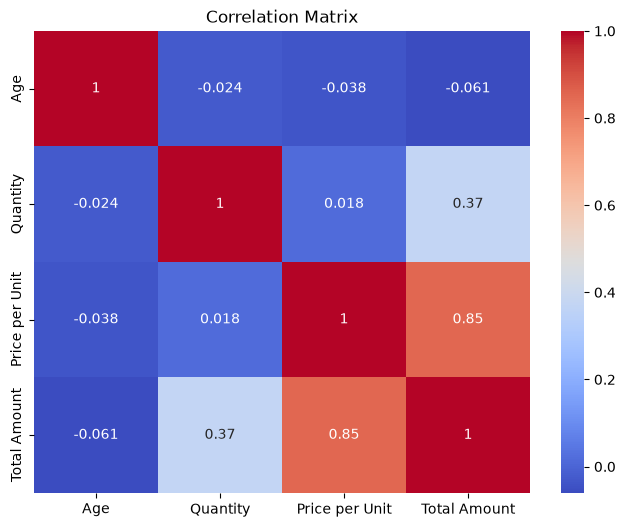

In [24]:

# Select only numerical columns from the dataset
# because correlation can be calculated only
# between numerical variables
numerical = df[
    [
        'Age',
        'Quantity',
        'Price per Unit',
        'Total Amount'
    ]
]

# Calculate the correlation matrix
# using Pearson correlation coefficient
correlation = numerical.corr()

# Display the correlation values
print("Correlation Matrix:")
print(correlation)

# Create a figure with width=8 and height=6
plt.figure(figsize=(8,6))

# Create the heatmap
sns.heatmap(
    correlation,      # Correlation matrix data
    annot=True,       # Display correlation values
    cmap='coolwarm'   # Color scheme
)

# Add title to the heatmap
plt.title('Correlation Matrix')

# Display the heatmap
plt.show()

##  Additional Business Insight

Average Spending by Age Group:
Age_Group
0-20     551.269841
21-30    467.690476
31-40    497.150259
41-50    424.411765
51-60    454.931818
60+      357.258065
Name: Total Amount, dtype: float64


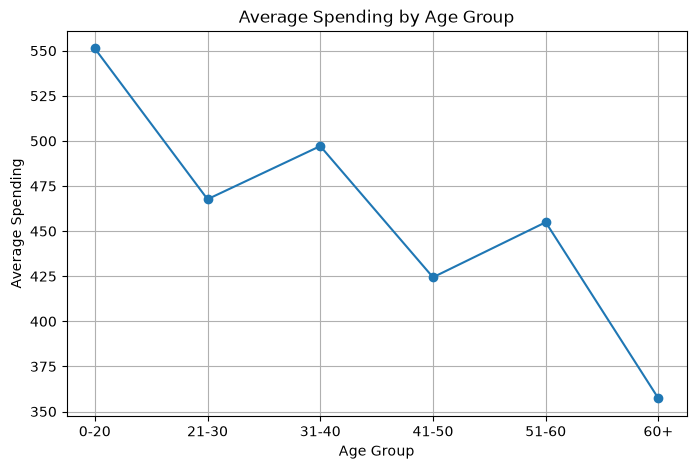

In [ ]:

# Average Spending by Age Group
# Define the age group ranges
bins = [
    0, 20, 30, 40,
    50, 60, 100
]

# Define labels for each age range
labels = [
    '0-20',
    '21-30',
    '31-40',
    '41-50',
    '51-60',
    '60+'
]

# Create a new column called Age_Group
# using the age ranges defined above
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

# Group the data by Age_Group
# and calculate the average spending
avg_spending = (
    df.groupby('Age_Group')
    ['Total Amount']
    .mean()
)

# Display average spending by age group
print("Average Spending by Age Group:")
print(avg_spending)

# Create a figure
plt.figure(figsize=(8,5))

# Plot the average spending as a line chart
avg_spending.plot(
    kind='line',
    marker='o'
)

# Add chart title
plt.title(
    'Average Spending by Age Group'
)
plt.xlabel= 'Age Group'

# Add y-axis label
plt.ylabel('Average Spending')

# Add grid lines for better readability
plt.grid(True)

# Display the chart
plt.show()

## Conclusion and Business Recommendations

# Conclusion

The Retail Sales Analysis project provided valuable insights into customer behavior, product performance, and sales trends through data analysis and visualization techniques. The analysis revealed that product category performance, customer demographics, pricing, and purchase quantity significantly influence overall business revenue. Additionally, sales trend analysis highlighted variations in customer demand over time, while demographic analysis identified middle-aged customers as a high-value customer segment.
Based on these findings, the following business recommendations are proposed:

# 1. Focus on High-Performing Product Categories

Increase investment, inventory, and promotional efforts for top-performing product categories to maximize revenue and profitability.

# 2. Target High-Value Customer Segments

Develop personalized marketing campaigns and loyalty programs for middle-aged customers (41–60 years), who demonstrate higher spending behavior.

# 3. Implement Cross-Selling and Promotional Strategies

Introduce product bundles, quantity discounts, and targeted promotions to increase average transaction value and overall sales performance.

# 4. Optimize Inventory Planning Using Sales Trends

Utilize monthly and quarterly sales patterns to improve inventory forecasting and operational efficiency.

# Final Remark

This project demonstrates how data analytics can transform raw business data into actionable insights, enabling organizations to make informed decisions, improve customer satisfaction, optimize operations, and achieve sustainable business growth.
